<a href="https://colab.research.google.com/github/mryalk59-oss/FDS/blob/main/Midterm_Alternative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [29]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [30]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [50]:
iris = Table.read_table('Iris.csv')
iris.show(5)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [51]:
# Q1. How many rows and columns does the dataset have? Print the column names.
print("Number of rows:", iris.num_rows)
print("Number of columns:", iris.num_columns)
print("Column names:", iris.labels)


Number of rows: 150
Number of columns: 6
Column names: ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [53]:
# Q2. How many flowers are there per species? Use the .group() method.
species_count = iris.group('Species')
print(species_count)


Species         | count
Iris-setosa     | 50
Iris-versicolor | 50
Iris-virginica  | 50


In [56]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.
petal_length = iris.column('PetalLengthCm')
petal_width = iris.column('PetalWidthCm')

print("PetalLength -> Mean:", np.mean(petal_length), "| Min:", np.min(petal_length), "| Max:", np.max(petal_length))
print("PetalWidth  -> Mean:", np.mean(petal_width),  "| Min:", np.min(petal_width),  "| Max:", np.max(petal_width))


PetalLength -> Mean: 3.75866666667 | Min: 1.0 | Max: 6.9
PetalWidth  -> Mean: 1.19866666667 | Min: 0.1 | Max: 2.5


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

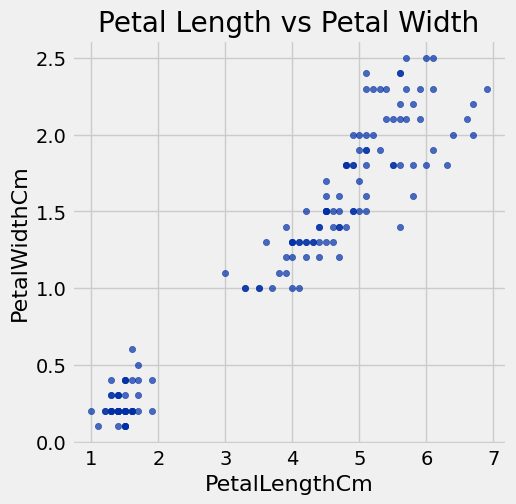

In [60]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.
iris.scatter('PetalLengthCm', 'PetalWidthCm')
plt.title('Petal Length vs Petal Width')
plt.show()

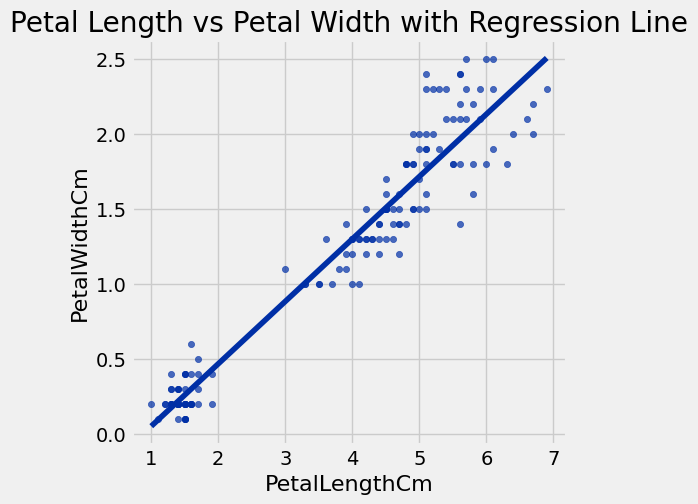

In [61]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.
iris.scatter('PetalLengthCm', 'PetalWidthCm', fit_line=True)
plt.title('Petal Length vs Petal Width with Regression Line')
plt.show()
#As the petal length increase, the petal width is also inceases, which shows there is a clear and strong positive relationship between the two.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [37]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [38]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [39]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [40]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [75]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.
m = slope(iris, 'PetalLengthCm', 'PetalWidthCm')
b = intercept(iris, 'PetalLengthCm', 'PetalWidthCm')

print(f"Slope: {m:.4f}")
print(f"Intercept: {b:.4f}")
print(f"Regression Equation: petal_width = {m:.4f} * petal_length + ({b:.4f})")

Slope: 0.4164
Intercept: -0.3665
Regression Equation: petal_width = 0.4164 * petal_length + (-0.3665)


In [76]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.
petal_length_value = 4.5
predicted_width = m * petal_length_value + b

print(f"Regression Equation: petal_width = {m:.4f} * petal_length + ({b:.4f})")
print(f"Calculation: petal_width = {m:.4f} * {petal_length_value} + ({b:.4f})")
print(f"Predicted petal_width for petal_length = 4.5 cm: {predicted_width:.4f} cm")

Regression Equation: petal_width = 0.4164 * petal_length + (-0.3665)
Calculation: petal_width = 0.4164 * 4.5 + (-0.3665)
Predicted petal_width for petal_length = 4.5 cm: 1.5074 cm


In [66]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.
r = correlation(iris, 'PetalLengthCm', 'PetalWidthCm')
print(f"Correlation coefficient r: {r:.4f}")
#The correlation coeddicient r measures how strongly two variables are related. so, in this case, r is close to 1 which means there is a strong positive relationship between petal length and petal width and as petal length inceases, petal width increases too.
#when the value near to 1 or -1 indicates strong (Positive or Negative) relationship, while a value near to 0 indicates a weak one.

Correlation coefficient r: 0.9628


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [73]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.predicted = m * iris.column('petal_length') + b
predicted = m * iris.column('PetalLengthCm') + b
residuals = iris.column('PetalWidthCm') - predicted

iris = iris.with_columns(
    'predicted_petal_width', predicted,
    'residuals', residuals
)
iris.show(8)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,predicted_petal_width,residuals,predicted_petalWidthCm
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727,0.216473
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727,0.216473
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692,0.174831
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147,0.258115
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727,0.216473
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015,0.341398
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273,0.216473
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147,0.258115


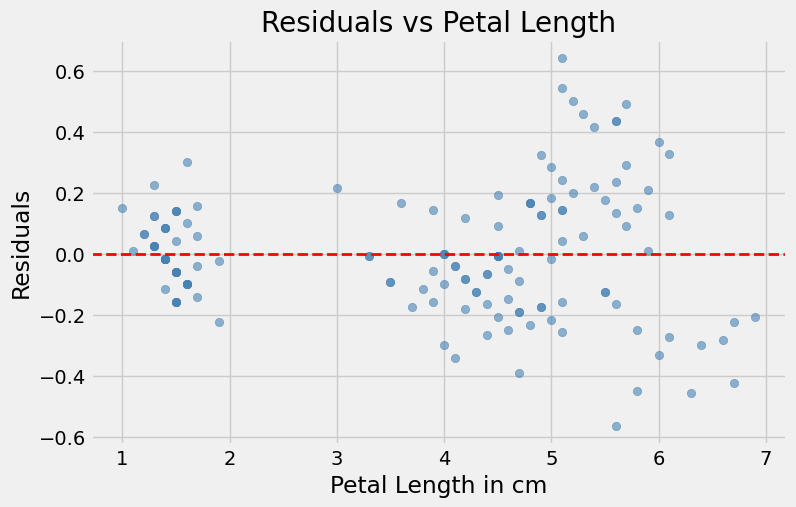

In [78]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.
plt.figure(figsize=(8, 5))
plt.scatter(iris.column('PetalLengthCm'), iris.column('residuals'), color='steelblue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Petal Length in cm')
plt.ylabel('Residuals')
plt.title('Residuals vs Petal Length')
plt.show()
# The residual plot shows the points spread randomly above and below zero,
# which means the linear regression model fits the data well but there is a bit more variation in the residuals when the petal length is larger.
# So, the model is a little less accurate for bigger values.
# Overall, since the points look random, it confirms that using a linear model is suitable for this data.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.